In [9]:
#데이터 분석
import numpy as np
import pandas as pd

#데이터 시각화
import seaborn as sns
import matplotlib.pyplot as plt

#머신러
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report

In [10]:
#한글 깨짐 방지
plt.rcParams['font.family'] = 'Malgun Gothic' # apple : 'AppleGothic'

# 마이너스 부호 깨짐 방지
import matplotlib.pyplot as plt
plt.rcParams['axes.unicode_minus'] = False

#경고문 패치
import warnings

warnings.filterwarnings('ignore')

In [11]:
df = sns.load_dataset("penguins") 
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [12]:
df.isnull().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

In [13]:
df.dropna(subset=['sex'],inplace=True)

In [14]:
df.isnull().sum()

species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64

In [15]:
df['species_target'] = df['species'].map({
    'Adelie' : 0,
    'Gentoo' : 1,
    'Chinstrap' : 2
})

In [16]:
#범주형 변수와 수치형 변수로 분리

categorical_cols = df.select_dtypes(exclude=['number']).columns
print(categorical_cols)

numeric_cols = df.select_dtypes(include=['number']).columns
print(numeric_cols)

Index(['species', 'island', 'sex'], dtype='object')
Index(['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g',
       'species_target'],
      dtype='object')


In [17]:
# 범주형 타깃과 수치형 특징간의 관계
for col in numeric_cols:
    print(f"--- {col} ---")
    print(df.groupby('species')[col].mean())
    print()

--- bill_length_mm ---
species
Adelie       38.823973
Chinstrap    48.833824
Gentoo       47.568067
Name: bill_length_mm, dtype: float64

--- bill_depth_mm ---
species
Adelie       18.347260
Chinstrap    18.420588
Gentoo       14.996639
Name: bill_depth_mm, dtype: float64

--- flipper_length_mm ---
species
Adelie       190.102740
Chinstrap    195.823529
Gentoo       217.235294
Name: flipper_length_mm, dtype: float64

--- body_mass_g ---
species
Adelie       3706.164384
Chinstrap    3733.088235
Gentoo       5092.436975
Name: body_mass_g, dtype: float64

--- species_target ---
species
Adelie       0.0
Chinstrap    2.0
Gentoo       1.0
Name: species_target, dtype: float64



In [18]:
# 수치형 타깃과 수치형 특징
for col in numeric_cols:
    corr = df[col].corr(df['species_target'])
    print(col, corr)

bill_length_mm 0.777472941112009
bill_depth_mm -0.1737893902588065
flipper_length_mm 0.3460612465526612
body_mass_g 0.19925919061850972
species_target 1.0


In [19]:
#수치형 타깃 & 범주형 타깃 범주형 특징
for i in categorical_cols:
    print(df.groupby('species_target')[i].value_counts())

species_target  species  
0               Adelie       146
1               Gentoo       119
2               Chinstrap     68
Name: count, dtype: int64
species_target  island   
0               Dream         55
                Torgersen     47
                Biscoe        44
1               Biscoe       119
2               Dream         68
Name: count, dtype: int64
species_target  sex   
0               Female    73
                Male      73
1               Male      61
                Female    58
2               Female    34
                Male      34
Name: count, dtype: int64


In [20]:
y = df['species']
X = pd.get_dummies(df[["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g", "island"]],
                   columns=["island"])

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    test_size = 0.2,
    random_state = 42,
    stratify = y 
)

In [22]:
model = DecisionTreeClassifier(
    max_depth = 3, #트리의 최대 깊이 제한
    random_state = 42)

In [24]:
model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [25]:
y_pred = model.predict(X_test)
#t_test.values
print(y_pred)

['Gentoo' 'Chinstrap' 'Adelie' 'Gentoo' 'Gentoo' 'Gentoo' 'Chinstrap'
 'Adelie' 'Adelie' 'Gentoo' 'Chinstrap' 'Adelie' 'Adelie' 'Chinstrap'
 'Adelie' 'Adelie' 'Chinstrap' 'Adelie' 'Chinstrap' 'Gentoo' 'Chinstrap'
 'Gentoo' 'Adelie' 'Adelie' 'Gentoo' 'Adelie' 'Adelie' 'Adelie' 'Gentoo'
 'Chinstrap' 'Gentoo' 'Adelie' 'Adelie' 'Adelie' 'Adelie' 'Adelie'
 'Gentoo' 'Gentoo' 'Adelie' 'Adelie' 'Adelie' 'Gentoo' 'Adelie' 'Gentoo'
 'Chinstrap' 'Adelie' 'Gentoo' 'Chinstrap' 'Gentoo' 'Chinstrap' 'Gentoo'
 'Adelie' 'Chinstrap' 'Adelie' 'Gentoo' 'Adelie' 'Adelie' 'Chinstrap'
 'Adelie' 'Gentoo' 'Adelie' 'Gentoo' 'Gentoo' 'Adelie' 'Gentoo' 'Adelie'
 'Adelie']


In [26]:
accuracy = accuracy_score(y_test, y_pred)
print("Decision Tree 정확도: ",round(accuracy,3))

Decision Tree 정확도:  0.955


In [29]:
print(classification_report(
    y_test,
    y_pred,
    target_names = df['species'].unique()
))

              precision    recall  f1-score   support

      Adelie       0.91      1.00      0.95        29
   Chinstrap       1.00      0.93      0.96        14
      Gentoo       1.00      0.92      0.96        24

    accuracy                           0.96        67
   macro avg       0.97      0.95      0.96        67
weighted avg       0.96      0.96      0.96        67



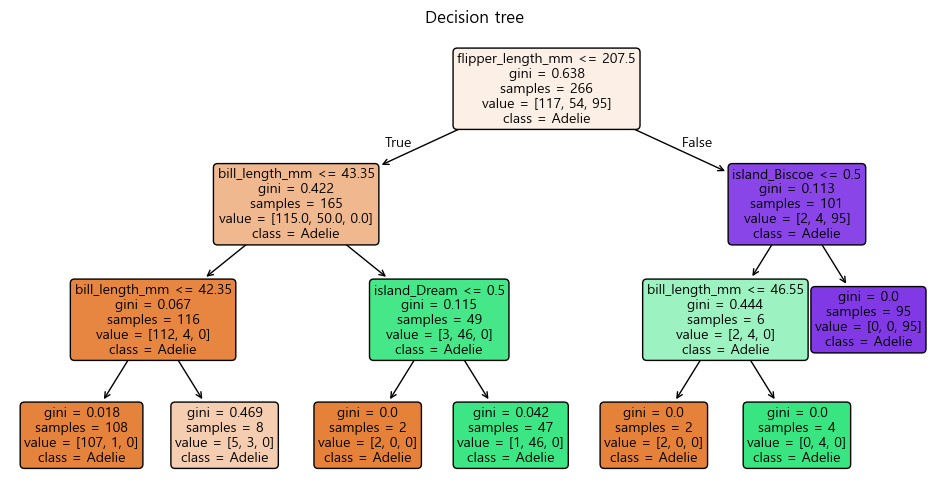

In [30]:
plt.figure(figsize= (12,6))
plot_tree(model, 
         feature_names = X.columns, #가장 잘 분류돠는 feature로 모델이 알아서 골라서 분류 수행
         class_names = y,
         filled = True,
         rounded = True,
         fontsize = 10)

plt.title('Decision tree')
plt.show()